# visualization

## Goal

The goal of this notebook is to make a motherfa*** amazing figure that gets us published in Nature.


In [74]:
import numpy as np 
import pandas as pd
import rasterio

import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# API_KEY = 'eea27551602d1407f983f4c5033bcb56'

In [67]:
tables1 = pd.read_excel("si.2025-10-27.xlsx", sheet_name='TableS1').drop_duplicates('site')[['site', 'habitat', 'longitude', 'latitude']]
tables1 = tables1.set_index('site').drop(['Q3;Q4', 'Q1;Q2;Q3']).reset_index()
tables1['altitude'] = 1000.0 + tables1['habitat'].apply(lambda x: {'Crop': 100, 'Wasteland': 200, 'Oak':300, 'Edge': 400}[x])
tables1

,site,habitat,longitude,latitude,altitude
0,C1,Crop,-3.593308,40.051302,1100.0
1,C2,Crop,-3.599064,40.043193,1100.0
2,E1,Wasteland,-3.500323,40.059138,1200.0
3,E2,Wasteland,-3.536191,40.234966,1200.0
4,E3,Wasteland,-3.196057,40.089637,1200.0
5,E4,Wasteland,-3.131139,40.494167,1200.0
6,H1,Crop,-3.477574,40.04933,1100.0
7,H2,Crop,-3.214026,40.085899,1100.0
8,H3,Crop,-3.253943,40.245852,1100.0
9,L1,Edge,-3.34522,40.03184,1400.0


In [68]:
x = tables1[['longitude']].astype('float')
y = tables1[['latitude']].astype('float')
x_min = np.min(x)
x_max = np.max(x)
y_min = np.min(y)
y_max = np.max(y)
# xx = np.arange(x_min, x_max, 0.25)
# yy = np.arange(y_min, y_max, 0.25)
# X, Y = np.meshgrid(xx, yy)
# XY = np.stack([X.flatten(), Y.flatten()], axis=1)
print(x_min, x_max)
print(y_min, y_max)

-3.599064 -3.125
39.59552 40.494167


In [69]:
data = rasterio.open('aranjuez3.tif')

In [75]:
Z = data.read(1)
Z = gaussian_filter(Z, sigma=1)
Z.shape
xx = np.linspace(x_min, x_max, Z.shape[1])
yy = np.linspace(y_min, y_max, Z.shape[0])
X, Y = np.meshgrid(xx, yy)
# XY = np.stack([X.flatten(), Y.flatten()], axis=1)

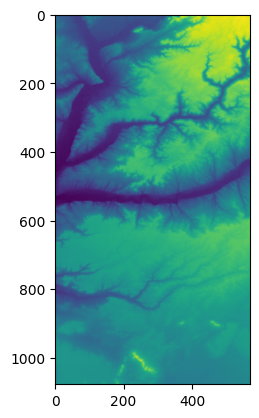

In [76]:
plt.imshow(Z)

In [78]:
earth_colors = [
    [0.0, "#167816"],   # Brown
    [0.2, "#167816"],   # SaddleBrown
    [0.4, "#E2E59D"],   # Chocolate
    [0.6, "#DDEF9A"],   # Peru
    [0.8, "#898312"],  # BurlyWood
    [1.0, "#A72A05"]   # Beige
]
palette = {
    "Crop": "#0CAB7B",
    "Edge": "#3A8DFA",
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}
    

  
  

fig = go.Figure(
    data=[
        go.Surface(
            x=xx, y=yy, z=Z, colorscale=earth_colors
        )
    ]
)

for _, point in tables1.iterrows():
    fig.add_trace(
        go.Scatter3d(
            x=[point["longitude"]],
            y=[point["latitude"]],
            z=[point['altitude']],
            mode="markers+text",
            marker=dict(size=6, color=palette[point['habitat']]),
            text=[point["site"]],
            textposition="top center",
            name=point["site"],
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=[point["longitude"], point["longitude"]],
            y=[point["latitude"], point["latitude"]],
            z=[point['altitude'], 0],  # From marker height to terrain (z=0 or actual terrain height)
            mode="lines",
            line=dict(color=palette[point['habitat']], width=2, dash="dot"),
            name=f"{point['site']} Line",
            showlegend=False,
        )
    )

fig.update_layout(title=dict(text='Mt Bruno Elevation'), autosize=True, 
                  width=900, height=900,
                  margin=dict(l=30, r=30, b=40, t=30),
                  scene=dict(
                      xaxis=dict(title='Longitude (º)'),  # Set x-axis label
        yaxis=dict(title='Latitude (º)'), 
        zaxis=dict(
            title='Altitude (m)',
            range=[min(Z.flatten()), 1500],  # Adjust the multiplier as needed,

        ),
        aspectratio=dict(x=3 * 0.474063, y=3 * 0.8986, z=1.0)
    )
                  )

fig.show()

In [95]:
x_max - x_min

np.float64(0.4740639999999998)

In [96]:
y_max - y_min

np.float64(0.8986469999999969)

In [38]:
coordinates.set_index('Site_code')['Longitude']

Site_code
C1   -3.593308
C1   -3.593308
C2   -3.599064
C2   -3.599064
E1   -3.500323
        ...   
Q4   -3.137145
Z1   -3.476076
Z1   -3.476076
Z2   -3.131000
Z2   -3.131000
Name: Longitude, Length: 78, dtype: float64

In [36]:
x_max

np.float64(-3.125)

In [37]:
xx

array([-3.599064  , -3.59862383, -3.59818366, ..., -3.12588034,
       -3.12544017, -3.125     ], shape=(1078,))

In [76]:
XYZ = pd.DataFrame(XY, columns=['lon', 'lat'])

In [77]:
import pandas as pd
import requests
import time

def get_elevation(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url).json()
    print(response)
    time.sleep(1)
    return response['results'][0]['elevation']

# Add elevation column
XYZ['elevation'] = XYZ.apply(lambda row: get_elevation(row['lat'], row['lon']), axis=1)
print(XYZ)


{'results': [{'latitude': 39.59552, 'longitude': -3.599064, 'elevation': 680.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.589064, 'elevation': 704.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.579064, 'elevation': 698.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.569064, 'elevation': 703.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.559064, 'elevation': 703.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.549064, 'elevation': 714.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.539064, 'elevation': 703.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.529064, 'elevation': 712.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.519064, 'elevation': 704.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.509064, 'elevation': 700.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.499064, 'elevation': 699.0}]}
{'results': [{'latitude': 39.59552, 'longitude': -3.489064, 'elevation': 707.0}]}
{'results': [{'l

KeyboardInterrupt: 

In [78]:
z_data = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv')

fig = go.Figure(
    data=[
        go.Surface(
            x=xx, y=yy,
            z=XYZ['elevation'].values.reshape((len(xx), len(yy)))
        )
    ]
)
fig.update_layout(title=dict(text='Mt Bruno Elevation'), autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

KeyError: 'elevation'

In [58]:
get_elevation(-3.599064, 39.59552)

285.0

In [64]:
z_data

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,0,27.809850,49.619360,83.080670,116.66320,130.41400,150.72060,220.18710,156.15360,148.64160,...,49.961420,21.89279,17.025520,11.743170,14.752260,13.667100,5.677561,3.312340,1.156517,-0.147662
1,1,27.719660,48.550220,65.213740,95.27666,116.99640,133.90560,152.34120,151.93400,160.11390,...,33.088710,38.40972,44.248430,69.578600,4.019351,3.050024,3.039719,2.996142,2.967954,1.999594
2,2,30.426700,33.477520,44.809530,62.47495,77.43523,104.21530,102.73930,137.00040,186.07060,...,48.471320,74.71461,60.090900,7.073525,6.089851,6.537450,6.666096,7.306965,5.736840,3.625628
3,3,16.665490,30.108600,39.969520,44.12225,59.57512,77.56929,106.89250,166.55390,175.23810,...,60.559160,55.92124,15.172840,8.248324,36.680870,61.934130,20.268670,68.588190,46.498120,0.236010
4,4,8.815617,18.351600,8.658275,27.58590,48.62691,60.18013,91.32860,145.71090,116.06530,...,47.426910,69.20731,44.954680,29.171970,17.916740,16.255150,14.655590,17.260480,31.222450,46.717040
5,5,6.628881,10.413390,24.819390,26.08952,30.16050,52.30802,64.71007,76.30823,84.63686,...,140.264700,81.26501,56.457560,30.421640,17.287820,8.302431,2.981626,2.698536,5.886086,5.268358
6,6,21.839750,6.639270,18.970850,32.89204,43.15014,62.86014,104.66570,130.22940,114.84940,...,122.422100,123.96980,109.095200,98.419560,77.613740,32.490310,14.673440,7.370775,0.037110,0.642339
7,7,53.343030,26.797970,6.639270,10.88787,17.20440,56.18116,79.70141,90.84530,98.27675,...,68.174900,46.24076,39.938570,31.216530,36.883350,40.025250,117.429700,12.703280,1.729771,0.000000
8,8,25.667850,63.057170,22.141400,17.07400,41.74483,60.27227,81.42432,114.44400,102.32340,...,59.193550,42.47175,14.635980,6.944074,6.944075,27.749360,0.000000,0.000000,0.094494,0.077323
9,9,12.827000,69.205540,46.762930,13.96517,33.88744,61.82613,84.74799,121.12200,145.27410,...,79.344250,25.93483,6.944074,6.944074,6.944075,7.553681,0.000000,0.000000,0.000000,0.000000
